## Fraud Detection system

In [1]:
# import necessary lib's

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading raw dataset file 

In [2]:
FILE_PATH=r'E:\45DaysML\projects\Fraud-detection\dataset\raw\Fraud.csv'
chunk_size=100_000
results=[]

with pd.read_csv(FILE_PATH, chunksize=chunk_size) as raw_dataset:
    for chunk in raw_dataset:
        results.append(chunk)

df = pd.concat(results, ignore_index=True)

### Total no. of rows and columns in the above dataset

In [3]:
rows, cols = df.shape

print(f"Total no. of rows: {rows} and columns: {cols}")

Total no. of rows: 6362620 and columns: 11


### Filter out all the column names

In [4]:
print(df.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


### Get the desc. regarding each column

In [5]:
with open(r"E:\45DaysML\projects\Fraud-detection\dataset\Data Dictionary.txt", mode='r') as file:
    print(file.read())

step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

amount - amount of the transaction in local currency.

nameOrig - customer who started the transaction

oldbalanceOrg - initial balance before the transaction

newbalanceOrig - new balance after the transaction

nameDest - customer who is the recipient of the transaction

oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to anot

**Observations**
From the above desc. we can cleary see that the columns like `nameOrig` and `nameDest` describes the CustomerID of *sender* and *receiver*. therefore, we're dropping these 2 columns.
<br/>
Another point, columns like `isFraud` is the column for which we've to predict so it's categorized into target variable not in training variables.
<br/>
We can also drop the column which is `isFlaggedFraud` as it only use a *step_fxn* to make decision, that is if amount > 200.000 then `fraud`.

In [6]:
columns_to_remove=['nameOrig', 'nameDest', 'isFlaggedFraud']
df.drop(columns=columns_to_remove, inplace=True)

In [7]:
print("Remaining columns are: ", df.columns)

Remaining columns are:  Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   oldbalanceDest  float64
 6   newbalanceDest  float64
 7   isFraud         int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 388.3+ MB


### Updating `dtype` of each columns
Doing this we're ensuring that it will occupy less memory while doing *EDA*.

In [21]:
df['step'] = df['step'].astype(np.int16)
df['amount'] = df['amount'].astype(np.float32)
df['oldbalanceOrg'] = df['oldbalanceOrg'].astype(np.float32)
df['newbalanceOrig'] = df['newbalanceOrig'].astype(np.float32)
df['oldbalanceDest'] = df['oldbalanceDest'].astype(np.float32)
df['newbalanceDest'] = df['newbalanceDest'].astype(np.float32)
df['isFraud'] = df['isFraud'].astype(np.int8)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int16  
 1   type            object 
 2   amount          float32
 3   oldbalanceOrg   float32
 4   newbalanceOrig  float32
 5   oldbalanceDest  float32
 6   newbalanceDest  float32
 7   isFraud         int8   
dtypes: float32(5), int16(1), int8(1), object(1)
memory usage: 188.1+ MB


### Check whether the dataset is balanced or imbalanced

<Axes: xlabel='isFraud'>

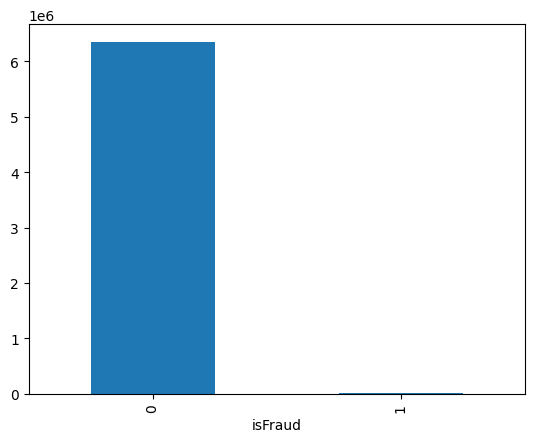

In [25]:
df['isFraud'].value_counts().plot(kind='bar')

In [31]:
t0 = df['isFraud'].value_counts()
print("Percentage of Fraud datapoints: ", (t0[1]/df.shape[0])*100)
print("Percentage of Not Fraud datapoints: ", (t0[0]/df.shape[0])*100)

Percentage of Fraud datapoints:  0.12908204481801522
Percentage of Not Fraud datapoints:  99.87091795518198


From the above graph and value_counts() operation, we can clearly see that the dataset is higly **imbalanced**. therefore, we need to utilize techniques like **SMOTE** or **Weight Assignment** to handle this situtation.
<br/>
As we know that, **SMOTE** generates the synthetic datapoints and make no. of datapoints of label `0` and `1` equal, it's better not to use this. Instead we'll use **weight assignment** technique for handling data imbalance.

### Saving the updated dataset

In [32]:
df.to_csv(r"E:\45DaysML\projects\Fraud-detection\dataset\preprocessed\updated_dataset.csv")